This is a writeup of how my team won the Portfolio Optimization Case in the 2025 UChicago Trading Competition. We wanted to take as scientific an approach as possible in this case; we didn't just want a blackbox of weight allocations. To do this, we really valued looking at the data itself and making the strategies we used fit the data, rather than applying random machine learning techniques 


In [12]:
#import data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from google.colab import drive
drive.mount('/content/drive')

file_path = "/content/drive/My Drive/Case2.csv"
data = pd.read_csv(file_path)

data.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Asset_1,Asset_2,Asset_3,Asset_4,Asset_5,Asset_6
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,1.000116,1.000057,1.000004,1.001425,0.999649,1.001650
2,0.999667,0.999739,1.000002,1.002474,0.999308,1.001552
3,1.000070,1.002696,1.000000,1.007441,1.001667,1.002308
4,1.000226,0.999711,1.000005,1.007110,1.001939,0.999043


Let's first take a look at what the returns of the assets look like

Text(0.5, 1.0, 'Asset Price Series')

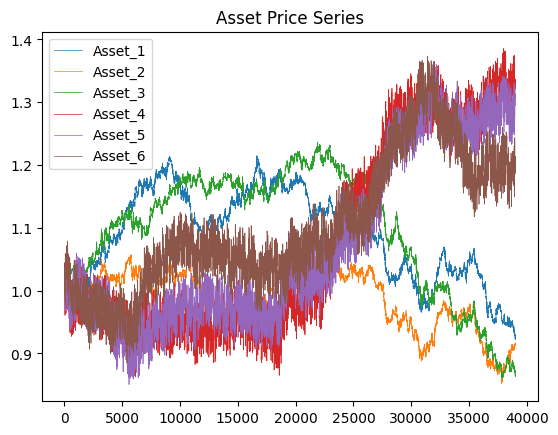

In [8]:
#make a plot of the graph

for i in range(1, 7):
    column = f"Asset_{i}"
    plt.plot(data[column], label=column, linewidth=0.5)  # Plot each asset's price series with thinner lines
    column_ret = f"Asset_{i}_ret"
    data[column_ret] = data[column].pct_change()  # Calculate percentage change for each asset
plt.legend()
plt.title("Asset Price Series")

Since there were so many ticks, we decided to zoom into the data to more clearly see the pattern of returns.

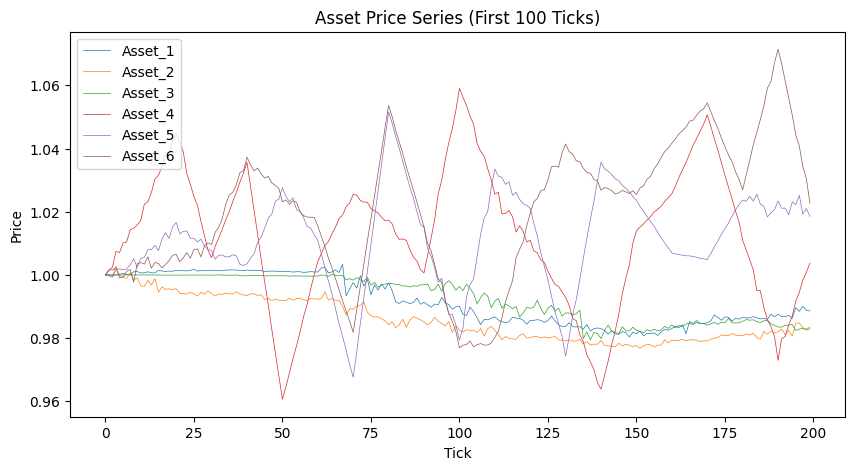

In [9]:
plt.figure(figsize=(10, 5))

for i in range(1, 7):
    column = f"Asset_{i}"
    plt.plot(data[column][:200], label=column, linewidth=0.5)  # Zoom to first 200 ticks

plt.legend()
plt.title("Asset Price Series (First 100 Ticks)")
plt.xlabel("Tick")
plt.ylabel("Price")
plt.show()


We can see a pretty stark difference between the structure of assets 1, 2, 3 and 4, 5, 6.

We can see a pattern that asset 4, 5 and 6 appear to follow a very linear pattern, particularly jumping around every ten ticks.

Let's take a closer look at assets 4, 5 and 6.


Text(0.5, 0.02, "Don't trade on the 10th tick")

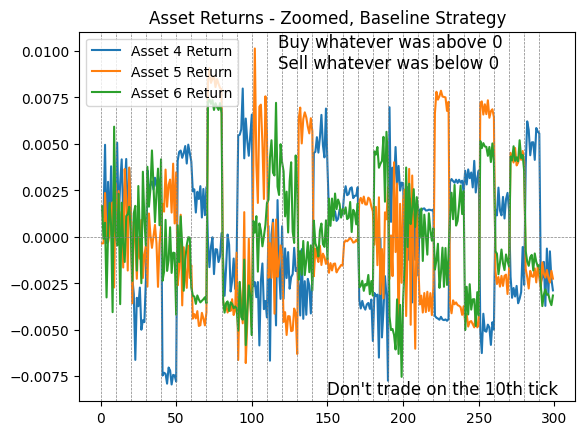

In [10]:
length = 300
plt.plot(data['Asset_4_ret'][0:length], label='Asset 4 Return')
plt.plot(data['Asset_5_ret'][0:length], label='Asset 5 Return')
plt.plot(data['Asset_6_ret'][0:length], label='Asset 6 Return')
for x in range(0, length, 10):
    plt.axvline(x=x, color='gray', linestyle='--', linewidth=0.5)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
plt.legend(loc='upper left')
plt.title("Asset Returns - Zoomed, Baseline Strategy")
plt.annotate("Buy whatever was above 0\nSell whatever was below 0 ", xy=(0.4, 0.9), xycoords='axes fraction', fontsize=12)
plt.annotate("Don't trade on the 10th tick", xy=(0.5, 0.02), xycoords='axes fraction', fontsize=12)

After plotting these few graphs, it became clear that there was a pattern in assets 4, 5 and 6. This realization laid the foundation for our first strategy.

In our first strategy, we only allocated weights to asset 4, 5 and 6; it placed a 1/3 weight to each asset. The strategy would buy if returns were above 0 and sell if returns were below 0; it would not trade on the tenth tick when the asset (most usually) would change direction.

In [13]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

TRAIN, TEST = train_test_split(data, test_size = 0.99, shuffle = False)

class Allocator():
    window_length = 500
    def __init__(self, train_data):
        '''
        Anything data you want to store between days must be stored in a class field
        '''
        self.running_price_paths = train_data.copy()

        self.train_data = train_data.copy()

        self.tick_number = len(self.running_price_paths) - 1
        self.asset_4_up = None
        self.asset_5_up = None
        self.asset_6_up = None
        # Do any preprocessing here -- do not touch running_price_paths, it will store the price path up to that data


    def allocate_portfolio(self, asset_prices):
        '''
        asset_prices: np array of length 6, prices of the 6 assets on a particular day
        weights: np array of length 6, portfolio allocation for the next day
        '''
        self.running_price_paths = pd.concat([self.running_price_paths, pd.DataFrame([asset_prices])], ignore_index=True)
        self.tick_number += 1

        # No allocation on this turn - unknown market conditions
        if self.tick_number % 10 == 0:
            return np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

        if self.tick_number % 10 == 1:
            # print("TICK NUMBER:", self.tick_number)
            recent_data = self.running_price_paths.tail(20).copy()
            recent_data['Asset_4_ret'] = recent_data['Asset_4'].pct_change()
            recent_data['Asset_5_ret'] = recent_data['Asset_5'].pct_change()
            recent_data['Asset_6_ret'] = recent_data['Asset_6'].pct_change()
            self.asset_4_up = recent_data['Asset_4_ret'].iloc[-1] > 0
            self.asset_5_up = recent_data['Asset_5_ret'].iloc[-1] > 0
            self.asset_6_up = recent_data['Asset_6_ret'].iloc[-1] > 0

        w4 = 0 if self.asset_4_up is None else (0.33 if self.asset_4_up else -0.33)
        w5 = 0 if self.asset_5_up is None else (0.33 if self.asset_5_up else -0.33)
        w6 = 0 if self.asset_6_up is None else (0.33 if self.asset_6_up else -0.33)

        return np.array([0.0, 0.0, 0.0, w4, w5, w6])

def grading(train_data, test_data):
    '''
    Grading Script
    '''
    weights = np.full(shape=(len(test_data.index),6), fill_value=0.0)
    alloc = Allocator(train_data)
    for i in range(0,len(test_data)):
        weights[i,:] = alloc.allocate_portfolio(test_data.iloc[i,:])
        if np.sum(weights < -1) or np.sum(weights > 1):
            raise Exception("Weights Outside of Bounds")

    capital = [1]
    for i in range(len(test_data) - 1):
        shares = capital[-1] * weights[i] / np.array(test_data.iloc[i,:])
        balance = capital[-1] - np.dot(shares, np.array(test_data.iloc[i,:]))
        net_change = np.dot(shares, np.array(test_data.iloc[i+1,:]))
        capital.append(balance + net_change)
    capital = np.array(capital)
    returns = (capital[1:] - capital[:-1]) / capital[:-1]

    if np.std(returns) != 0:
        returns = returns
        sharpe = np.mean(returns) / np.std(returns)
    else:
        sharpe = 0

    return sharpe, returns

sharpe_1, returns_1 = grading(TRAIN, TEST)
print(f"Sharpe: {sharpe_1}")

Sharpe: 1.3688985271838863


The sharpe for the initial strategy was about 1.37, which was quite promising considering this baseline strategy did not have much nuance.

We decided to investigate what the returns looked like.

Percent of returns less than 0: 4.312466005335543%


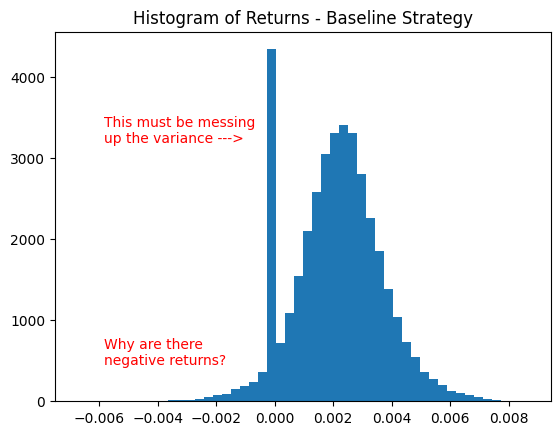

In [14]:
plt.hist(returns_1, bins=50)
plt.title("Histogram of Returns - Baseline Strategy")
plt.annotate(f"This must be messing\nup the variance --->", xy=(0.1, 0.7), xycoords='axes fraction', fontsize=10, color='red')
plt.annotate(f"Why are there\nnegative returns?", xy=(0.1, 0.1), xycoords='axes fraction', fontsize=10, color='red')
print(f"Percent of returns less than 0: {100*len(returns_1[returns_1 < 0])/len(returns_1)}%")

This plot illustrated two important findings/questions:

1) There was a huge spike of "0" returns. This spike presumably was from our strategy not trading on the tenth ticks.   
2) what was causing the negative returns?

**Optimization 1: Fixing the negative returns**

Since the assets were all either consitently up, down or bouncy between tick i to i + 10, we determined that the negative returns must come from the model not predicting accurately during those bouncy return periods.

In [15]:
class Allocator():
    window_length = 500
    def __init__(self, train_data):
        '''
        Anything data you want to store between days must be stored in a class field
        '''
        self.running_price_paths = train_data.copy()

        self.train_data = train_data.copy()

        self.tick_number = len(self.running_price_paths) - 1
        # Do any preprocessing here -- do not touch running_price_paths, it will store the price path up to that data


    def allocate_portfolio(self, asset_prices):
        '''
        asset_prices: np array of length 6, prices of the 6 assets on a particular day
        weights: np array of length 6, portfolio allocation for the next day
        '''
        self.running_price_paths = pd.concat([self.running_price_paths, pd.DataFrame([asset_prices])], ignore_index=True)
        self.tick_number += 1

        # No allocation on this turn - unknown market conditions
        idx = self.tick_number % 10
        if idx == 0:
            return np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
        #This is to make sure it doesn't run until we get to an index 1 the first time
        else:
            recent_data = self.running_price_paths[['Asset_4', 'Asset_5', 'Asset_6']].tail(idx+1).copy()
            recent_data['Asset_4_ret'] = recent_data['Asset_4'].pct_change()
            recent_data['Asset_5_ret'] = recent_data['Asset_5'].pct_change()
            recent_data['Asset_6_ret'] = recent_data['Asset_6'].pct_change()
            recent_data = recent_data.dropna()

            #New addition
            w4 = 0 if (recent_data['Asset_4_ret'].min() < 0 and recent_data['Asset_4_ret'].max() > 0) else (1 if recent_data['Asset_4_ret'].min() > 0 else -1)
            w5 = 0 if (recent_data['Asset_5_ret'].min() < 0 and recent_data['Asset_5_ret'].max() > 0) else (1 if recent_data['Asset_5_ret'].min() > 0 else -1)
            w6 = 0 if (recent_data['Asset_6_ret'].min() < 0 and recent_data['Asset_6_ret'].max() > 0) else (1 if recent_data['Asset_6_ret'].min() > 0 else -1)

            return np.array([0.0, 0.0, 0.0, w4, w5, w6])

sharpe_2, returns_2 = grading(TRAIN, TEST)
print(f"Sharpe: {sharpe_2}")

Sharpe: 1.3581152800934595


The sharpe is about the same (even slightly lower), but let's plot the historgrams of both strategies on top of each other to see what's going on.

Text(0.5, 1.0, 'Histogram of Returns - 2')

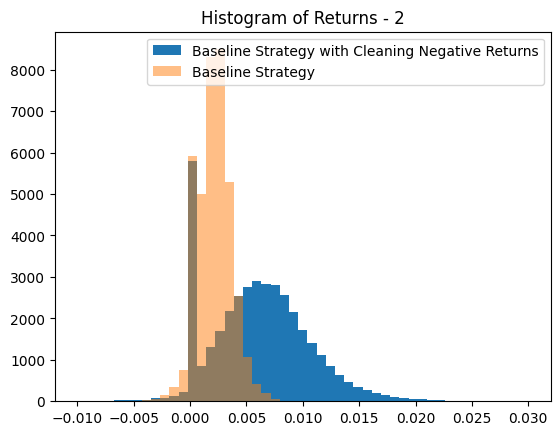

In [16]:
bins = np.linspace(-0.01, 0.03, 50)
plt.hist(returns_2, bins=bins, label="Baseline Strategy with Cleaning Negative Returns")
plt.hist(returns_1, bins=bins, alpha=0.5, label="Baseline Strategy")
plt.legend()
plt.title("Histogram of Returns - 2")

The brown region is the overlap between both strategies. The plot shows that this second strategy had higher returns than the first (as its right tail is so extended), but it still had a lower sharpe. We hypothesized that this was because it was taking on more risk, so much so that the variance (the denominator for sharpe) was increasing faster than this right tail (the returns/numerator), thus causing the sharpe to decrease.

We then decided to see what would happen if we only traded the asset with the highest return


In [17]:
class Allocator():
    window_length = 500
    def __init__(self, train_data):
        '''
        Anything data you want to store between days must be stored in a class field
        '''
        self.running_price_paths = train_data.copy()

        self.train_data = train_data.copy()

        self.tick_number = len(self.running_price_paths) - 1
        # Do any preprocessing here -- do not touch running_price_paths, it will store the price path up to that data


    def allocate_portfolio(self, asset_prices):
        '''
        asset_prices: np array of length 6, prices of the 6 assets on a particular day
        weights: np array of length 6, portfolio allocation for the next day
        '''
        self.running_price_paths = pd.concat([self.running_price_paths, pd.DataFrame([asset_prices])], ignore_index=True)
        self.tick_number += 1

        # No allocation on this turn - unknown market conditions
        idx = self.tick_number % 10
        if idx == 0:
            return np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
        else:
            recent_data = self.running_price_paths[['Asset_4', 'Asset_5', 'Asset_6']].tail(idx+1).copy()
            recent_data['Asset_4_ret'] = recent_data['Asset_4'].pct_change()
            recent_data['Asset_5_ret'] = recent_data['Asset_5'].pct_change()
            recent_data['Asset_6_ret'] = recent_data['Asset_6'].pct_change()
            recent_data = recent_data.dropna()
            means = recent_data[['Asset_4_ret', 'Asset_5_ret', 'Asset_6_ret']].mean()
            abs_means = means.abs()
            max_idx = abs_means.idxmax()
            column_to_index = {'Asset_4_ret': 3, 'Asset_5_ret': 4, 'Asset_6_ret': 5}
            answer = np.zeros(6)
            answer[column_to_index[max_idx]] = 1 * np.sign(means[max_idx])
            return answer

sharpe_3, returns_3 = grading(TRAIN, TEST)
print(f"Sharpe: {sharpe_3}")

Sharpe: 1.4103444318523786


This improved the sharpe a bit; let's again see the histogram plots.

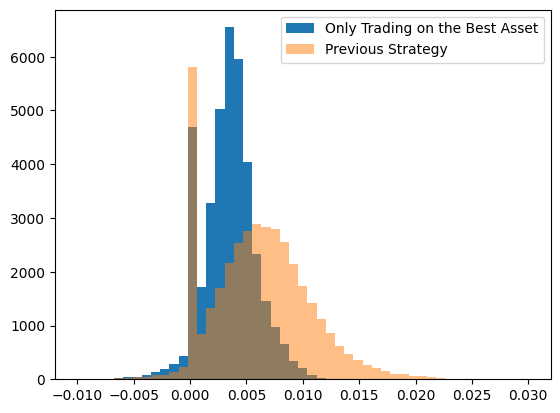

In [18]:
bins = np.linspace(-0.01, 0.03, 50)
plt.hist(returns_3, bins=bins, label="Only Trading on the Best Asset")
plt.hist(returns_2, bins=bins, alpha=0.5, label="Previous Strategy")
plt.legend()

This strategy seemed to work a bit better. Its right tail is not nearly as extended which may be the reason why its sharpe was higher (returns were lower, but so was the variance).

This realization led us to hypothesize that we may be able to increase the sharpe by actually capping the return; we presumed that there was a certain point in the data where the additional return we were getting was actually increasing the variance faster than the return itself.

We thought if we capped returns above a certain threshold, we could lower the variance and thus increase the sharpe. We tried capping returns through values 0 and the max return, and we found that capping the return at a value close to the mean reduced the variance the most. We also still wanted to preserve the strategy of only trading the asset with the highest return, as it seemed to work better in the last iteration of the strategy.

In [19]:
class Allocator():
    window_length = 500
    def __init__(self, train_data):
        '''
        Anything data you want to store between days must be stored in a class field
        '''
        self.running_price_paths = train_data.copy()

        self.train_data = train_data.copy()

        self.tick_number = len(self.running_price_paths) - 1
        # Do any preprocessing here -- do not touch running_price_paths, it will store the price path up to that data


    def allocate_portfolio(self, asset_prices):
        '''
        asset_prices: np array of length 6, prices of the 6 assets on a particular day
        weights: np array of length 6, portfolio allocation for the next day
        '''
        self.running_price_paths = pd.concat([self.running_price_paths, pd.DataFrame([asset_prices])], ignore_index=True)
        self.tick_number += 1

        # No allocation on this turn - unknown market conditions
        idx = self.tick_number % 10
        if idx == 0:
            return np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
        else: #Note: there is a strong negative autocorelation on the last change in return to this one. see what I can do with that later
            assets = ['Asset_4', 'Asset_5', 'Asset_6']
            next_returns = [0, 0, 0]
            recent_data = self.running_price_paths[assets].tail(idx+1).copy()
            for i, asset in enumerate(assets):
                value = recent_data[asset].pct_change().mean()
                next_returns[i] = value

            answer = np.zeros(6)
            max_idx = np.argmax(np.abs(next_returns))
            expected_return = abs(next_returns[max_idx])
            target_return = 0.0036
            if expected_return > target_return:
                weight = target_return / expected_return
            else:
                weight = 1
            answer[max_idx+3] = weight * np.sign(next_returns[max_idx])
            return answer

sharpe_4, returns_4 = grading(TRAIN, TEST)
print(f"Sharpe: {sharpe_4}")

Sharpe: 1.570664284653834


The sharpe is already looking a lot better! Let's plot the histogram again.

Text(0.8, 0.2, 'Left tail\ngets killed')

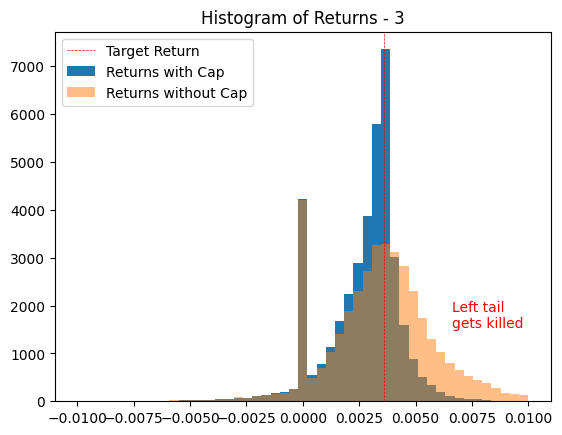

In [20]:
plt.axvline(x=0.0036, color='red', linestyle='--', linewidth=0.5, label='Target Return')
bins = np.linspace(-0.01, 0.01, 50)
plt.hist(returns_4, bins=bins, alpha=1, label='Returns with Cap')
plt.hist(returns_3, bins=bins, alpha=0.5, label='Returns without Cap')
plt.title("Histogram of Returns - 3")
plt.legend()
plt.annotate("Left tail\ngets killed", xy=(0.8, 0.2), xycoords='axes fraction', fontsize=10, color='red')


Evidently, adding the return cap improved our strategy drastically as it totally cut off the right tail of returns.

We were quite happy with this strategy, but we still sought to make it better by reducing the left tail where returns were lower than the target return. To do this, we considered removing the mandate we had initially set of not trading on the tenth tick. At first we were apprehensive to do this because if the pattern of asset's returns shifted by even a tick, this trade would produce a lot of risk; however, we were confident in the pattern we had found and decided to code this trade in.

In [21]:
class Allocator():
    window_length = 500
    def __init__(self, train_data):
        '''
        Anything data you want to store between days must be stored in a class field
        '''
        self.running_price_paths = train_data.copy()

        self.train_data = train_data.copy()

        self.tick_number = len(self.running_price_paths) - 1
        # Do any preprocessing here -- do not touch running_price_paths, it will store the price path up to that data


    def allocate_portfolio(self, asset_prices):
        '''
        asset_prices: np array of length 6, prices of the 6 assets on a particular day
        weights: np array of length 6, portfolio allocation for the next day
        '''
        self.running_price_paths = pd.concat([self.running_price_paths, pd.DataFrame([asset_prices])], ignore_index=True)
        self.tick_number += 1

        idx = self.tick_number % 10
        if idx == 0: #expect the return to be opposite of the last one - weigh equally
            recent_data = self.running_price_paths.tail(2).copy()
            target = 0.33
            w4 = -target if recent_data['Asset_4'].pct_change().iloc[-1] > 0 else target
            w5 = -target if recent_data['Asset_5'].pct_change().iloc[-1] > 0 else target
            w6 = -target if recent_data['Asset_6'].pct_change().iloc[-1] > 0 else target
            return np.array([0.0, 0.0, 0.0, w4, w5, w6])
        else: #Note: there is a strong negative autocorelation on the last change in return to this one. see what I can do with that later
            assets = ['Asset_4', 'Asset_5', 'Asset_6']
            next_returns = [0, 0, 0]
            recent_data = self.running_price_paths[assets].tail(idx+1).copy()
            for i, asset in enumerate(assets):
                if recent_data[asset].pct_change().min() < 0 and recent_data[asset].pct_change().max() > 0:
                    value = 0
                else:
                    value = recent_data[asset].pct_change().mean()
                next_returns[i] = value

            answer = np.zeros(6)
            max_idx = np.argmax(np.abs(next_returns))
            expected_return = abs(next_returns[max_idx])
            target_return = 0.0036
            if expected_return > target_return:
                weight = target_return / expected_return
                expected_return = target_return
            else:
                weight = 1

            answer[max_idx+3] = weight * np.sign(next_returns[max_idx])
            return answer

sharpe_5, returns_5 = grading(TRAIN, TEST)
print(f"Sharpe: {sharpe_5}")

Sharpe: 1.7306987660831852


This strategy gave us an even higher (and the winning) sharpe! We had reached the deadline for submission at this point, but if we had more time, would have potentially tried to make the following improvements:

1) Figuring out a better way to deal with when all the assets were bouncing near 0 - potentially placing equal weight in each asset.

2) We still had a left tail (of negative returns) in the final strategy. To fix this, we could have implemented some ML techniques.